In [1]:
import EFC_learningfMRI.globals as gl
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import nitools as nt
from EFC_learningfMRI.vis import plot_im_sess, custom_legend
from imaging_pipelines.vis import plot_surf
import PcmPy as pcm
from EFC_learningfMRI.G_matrix import G_sorted
from EFC_learningfMRI.util import get_trained_and_untrained, ttest_im_sess
from EFC_learningfMRI.pcm import make_models
from matplotlib.colors import LinearSegmentedColormap, Normalize
import statsmodels.formula.api as smf
import itertools
import nibabel as nb
import warnings

warnings.filterwarnings('ignore')

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [2]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants

# Representational geometry at session 3

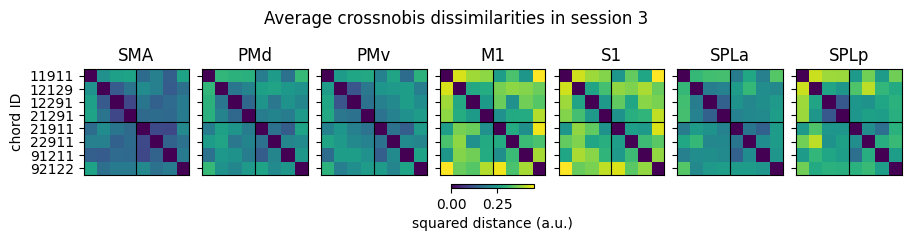

In [3]:
session = 3

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(9, 2.3))

vmin, vmax = 0, .45

for r, roi in enumerate(rois):
    G  = []
    for sn in sns:
        G.append(np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', f'G_obs_raw.within_session.{session}.glm{glm}.{H}.{roi}.npy')))
    G  = np.array(G)

    ax = axs[r]
    G_sort  = G_sorted(G, sns, order=gl.chordID)
    D  = pcm.G_to_dist(G_sort)
    D  = np.sign(D) * np.sqrt(np.abs(D))
    im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([])
    ax.set_yticks(np.arange(8))
    #ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticklabels(gl.chordID)
    ax.set_title(roi)

axs[0].set_ylabel('chord ID')

fig.colorbar(im, ax=axs, fraction=.03, label='squared distance (a.u.)', orientation='horizontal')

fig.suptitle(f'Average crossnobis dissimilarities in session 3')

fig.savefig(f'figures/crossnobis_example_{sn}.pdf')

plt.show()

# Crossnobis dissimilarities between activity patterns for trained and untrained chords (ROI-based)
In M1, activity patterns for trained chords on session 23 are (slightly) more distant among each other compared to untrained chords.

           T  dof     p_val           CI95   roi  session
0  -0.536513   15  0.599471  [-0.02, 0.01]   SMA        3
3  -0.339298   15  0.739089  [-0.02, 0.01]   PMd        3
6  -0.512439   15  0.615806  [-0.03, 0.02]   PMv        3
9  -0.316506   15  0.755981  [-0.05, 0.04]    M1        3
12 -0.622612   15  0.542890  [-0.04, 0.02]    S1        3
15 -1.163322   15  0.262871  [-0.05, 0.01]  SPLa        3
18 -0.865556   15  0.400366  [-0.05, 0.02]  SPLp        3
1   0.171311   15  0.866269  [-0.02, 0.02]   SMA        9
4  -1.050129   15  0.310284  [-0.03, 0.01]   PMd        9
7  -0.196098   15  0.847165  [-0.03, 0.03]   PMv        9
10  0.926154   15  0.369028  [-0.02, 0.05]    M1        9
13  0.860983   15  0.402801  [-0.03, 0.06]    S1        9
16 -0.035643   15  0.972037  [-0.03, 0.03]  SPLa        9
19 -0.145276   15  0.886427  [-0.03, 0.03]  SPLp        9
2  -0.843297   15  0.412309  [-0.01, 0.01]   SMA       23
5  -0.383190   15  0.706955  [-0.02, 0.01]   PMd       23
8  -2.028013  

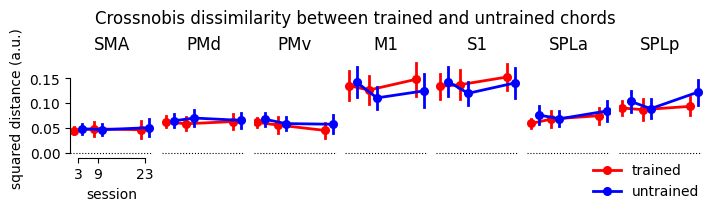

In [4]:
hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

dist = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist = dist[(dist.Hem=='L') & (dist.chord.isin(hue_order))]
dist_chord_sess = dist.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

#plot_im_sess(fig, axs, diss_within, rois, y='dist', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='box', legend=False, alpha=.3)
plot_im_sess(fig, axs, dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Crossnobis dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/crossnobis_mean.pdf')

plt.show()

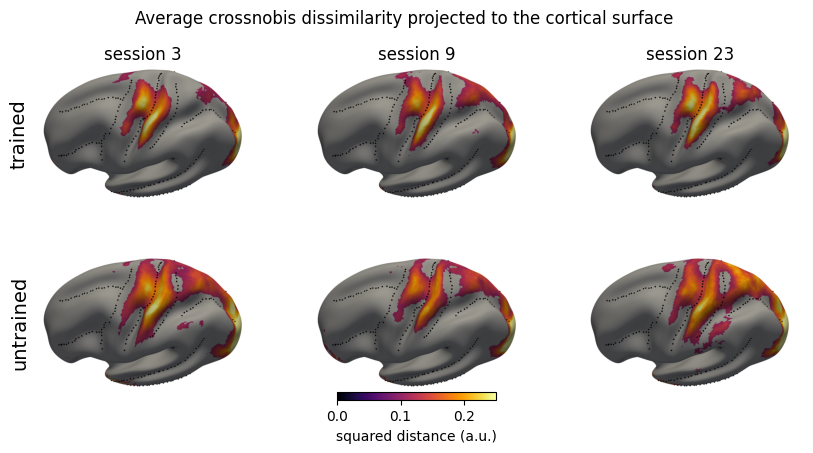

In [5]:
thresh = .1
vmin, vmax = 0, .25
H = 'L'

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 4.5), )

cmap = 'inferno'

for s, session in enumerate(gl.sessions):
    ax       = axs[:, s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_crossnobis.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    tr_col   = cols.index('crossnobis-trained')
    untr_col = cols.index('crossnobis-untrained')
    plot_surf(fig, ax[0], gifti, H, cmap=cmap, col=tr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    plot_surf(fig, ax[1], gifti, H, cmap=cmap, col=untr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax[0].set_title(f'session {session}')

sm  = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
cax = axs[1, 1].inset_axes([.15, -.10, .7, .06])          # x0, y0, w, h in axes fractions
fig.colorbar(sm, cax=cax, orientation='horizontal', label='squared distance (a.u.)')

axs[0, 0].text(0, .5, 'trained', transform=axs[0, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)
axs[1, 0].text(0, .5, 'untrained', transform=axs[1, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)

fig.suptitle('Average crossnobis dissimilarity projected to the cortical surface')

fig.savefig('figures/crossnobis_searchlight.pdf')

plt.show()

# Cosine dissimilarity and angular distance between activity patterns for trained and untrained chords
The cosine dissimilarity and angular distance between activity patterns for trained chords are bigger compared to untrained chords.

           T  dof     p_val           CI95   roi  session
0  -0.636023   15  0.534347  [-0.01, 0.01]   SMA        3
3  -0.149696   15  0.882999  [-0.01, 0.01]   PMd        3
6  -0.609885   15  0.551066  [-0.02, 0.01]   PMv        3
9  -0.779728   15  0.447680  [-0.02, 0.01]    M1        3
12 -0.527081   15  0.605846  [-0.02, 0.01]    S1        3
15 -0.570809   15  0.576582  [-0.02, 0.01]  SPLa        3
18 -0.685596   15  0.503427  [-0.02, 0.01]  SPLp        3
1  -0.390236   15  0.701848  [-0.01, 0.01]   SMA        9
4   0.043138   15  0.966160  [-0.01, 0.01]   PMd        9
7   0.534853   15  0.600591  [-0.01, 0.01]   PMv        9
10 -0.171448   15  0.866163  [-0.01, 0.01]    M1        9
13  1.404976   15  0.180399   [-0.0, 0.02]    S1        9
16  1.290800   15  0.216314   [-0.0, 0.02]  SPLa        9
19 -0.647910   15  0.526837  [-0.01, 0.01]  SPLp        9
2   0.270175   15  0.790707  [-0.01, 0.02]   SMA       23
5   0.698487   15  0.495560  [-0.01, 0.01]   PMd       23
8   1.516005  

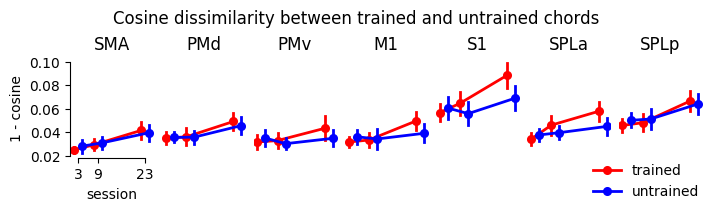

In [6]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess, rois, y='cosine', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('1 - cosine')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Cosine dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='cosine', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/cosine_mean.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.199836   15  0.844293  [-0.05, 0.04]   SMA        3
3  -0.237246   15  0.815675  [-0.04, 0.03]   PMd        3
6  -0.489852   15  0.631325  [-0.05, 0.03]   PMv        3
9  -0.405120   15  0.691108  [-0.06, 0.04]    M1        3
12 -0.140027   15  0.890501  [-0.05, 0.04]    S1        3
15 -0.630833   15  0.537644  [-0.06, 0.03]  SPLa        3
18 -0.683744   15  0.504563  [-0.06, 0.03]  SPLp        3
1  -0.450583   15  0.658735  [-0.04, 0.03]   SMA        9
4  -0.500050   15  0.624296  [-0.04, 0.03]   PMd        9
7  -0.005777   15  0.995466  [-0.04, 0.04]   PMv        9
10  0.074932   15  0.941259  [-0.04, 0.04]    M1        9
13  1.040655   15  0.314520  [-0.02, 0.07]    S1        9
16  0.824878   15  0.422365  [-0.02, 0.05]  SPLa        9
19 -0.367968   15  0.718038  [-0.04, 0.03]  SPLp        9
2   0.074789   15  0.941371  [-0.05, 0.06]   SMA       23
5   0.695185   15  0.497568  [-0.02, 0.05]   PMd       23
8   0.998607  

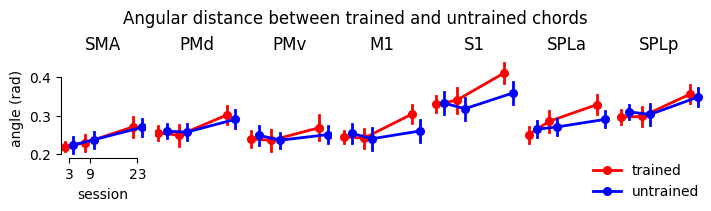

In [7]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

dist_chord_sess['theta'] = np.arccos(1 - dist_chord_sess.cosine)

plot_im_sess(fig, axs, dist_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Angular distance between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/angle_mean.pdf')

plt.show()

# Distances adjusted based on group geometry on session 3
For 8 chords, there are 70 possible sets of trained and untrained chords. While each chord was trained in half participants and untrained in the other half, the combination of trained and untrained chords was unique in each participants. Because we only collected N=16 participants, we could not sample all the possible combinations. Therefore, is possible that the underlying geometry in each participant influences the mean distances. To account for this, we regressed out the mean geometry at session 3 across participants from the crossnobis and cosine dissimilarities in each session, as follows:

...

adjusted for group
           T  dof     p_val           CI95   roi  session
0  -0.047005   15  0.963129  [-0.02, 0.02]   SMA        3
3  -0.019706   15  0.984537  [-0.02, 0.02]   PMd        3
6  -0.282921   15  0.781104  [-0.03, 0.02]   PMv        3
9  -0.687784   15  0.502086  [-0.04, 0.02]    M1        3
12 -0.544281   15  0.594247  [-0.03, 0.02]    S1        3
15 -0.968531   15  0.348138  [-0.04, 0.02]  SPLa        3
18 -0.746256   15  0.467048  [-0.04, 0.02]  SPLp        3
1   0.492129   15  0.629753  [-0.02, 0.03]   SMA        9
4  -1.015461   15  0.325986  [-0.03, 0.01]   PMd        9
7   0.003448   15  0.997295  [-0.03, 0.03]   PMv        9
10  0.682981   15  0.505031  [-0.03, 0.06]    M1        9
13  1.327131   15  0.204313  [-0.01, 0.05]    S1        9
16  0.301738   15  0.766995  [-0.02, 0.03]  SPLa        9
19  0.129909   15  0.898365  [-0.02, 0.02]  SPLp        9
2  -0.106022   15  0.916970  [-0.02, 0.02]   SMA       23
5  -0.017038   15  0.986631  [-0.02, 0.02]   PMd     

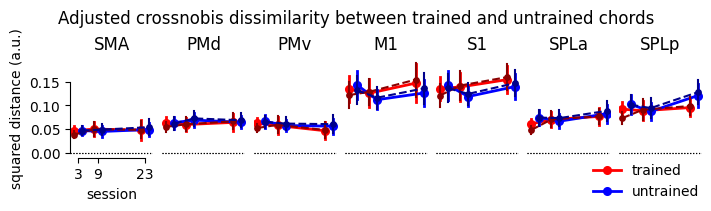

In [45]:
# adjusted for the group geometry only, and for the group + the subject's own force (der) geometry
dist_ancova = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist_ancova = dist_ancova[dist_ancova.Hem==H]
dist_chord_sess_ancova = dist_ancova.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

dist_ancova_force = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova_force_only.der.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist_ancova_force = dist_ancova_force[dist_ancova_force.Hem==H]
dist_chord_sess_ancova_force = dist_ancova_force.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

adjusted = {'group': dist_chord_sess_ancova, 'group + force': dist_chord_sess_ancova_force}

# group only: solid; group + force: dotted, narrower
linestyle = {'group': dict(ls='-', lw=2), 'group + force': dict(ls='--', lw=1.5)}
palette_ancova = {'group': palette, 'group + force': ['darkred', 'darkblue']}

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

for a, (label, df) in enumerate(adjusted.items()):
        plot_im_sess(fig, axs, df, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette_ancova[label], kind='point', estimator='mean', dodge=.4, add_zero=True, legend=a==0, **linestyle[label])

        ttest = ttest_im_sess(df, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
        ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
        ttest.sort_values(by=['session', 'roi'], inplace=True)

        print(f'adjusted for {label}')
        print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[0].set_xlabel('session')

fig.suptitle('Adjusted crossnobis dissimilarity between trained and untrained chords')

plt.show()


adjusted for group
           T  dof     p_val           CI95   roi  session
0   0.047695   15  0.962589  [-0.01, 0.01]   SMA        3
3   0.649123   15  0.526074  [-0.01, 0.01]   PMd        3
6  -0.496184   15  0.626956  [-0.01, 0.01]   PMv        3
9  -0.526338   15  0.606349  [-0.01, 0.01]    M1        3
12  0.139487   15  0.890921  [-0.01, 0.01]    S1        3
15 -0.382232   15  0.707651  [-0.01, 0.01]  SPLa        3
18 -0.070718   15  0.944557  [-0.01, 0.01]  SPLp        3
1   0.422316   15  0.678785  [-0.01, 0.01]   SMA        9
4   0.456472   15  0.654591  [-0.01, 0.02]   PMd        9
7   0.586804   15  0.566063  [-0.01, 0.02]   PMv        9
10  0.251634   15  0.804739  [-0.01, 0.01]    M1        9
13  1.597051   15  0.131103   [-0.0, 0.03]    S1        9
16  1.539414   15  0.144530   [-0.0, 0.02]  SPLa        9
19  0.104362   15  0.918265  [-0.01, 0.02]  SPLp        9
2   0.622662   15  0.542858  [-0.01, 0.02]   SMA       23
5   1.286508   15  0.217768   [-0.0, 0.02]   PMd     

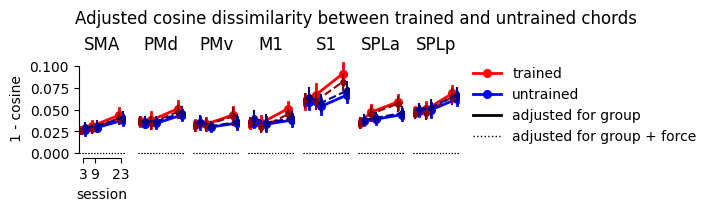

In [46]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

for a, (label, df) in enumerate(adjusted.items()):
        plot_im_sess(fig, axs, df, rois, y='cosine', x='session', hue='chord', hue_order=hue_order, palette=palette_ancova[label], kind='point', estimator='mean', dodge=.4, add_zero=True, legend=a==0, **linestyle[label])

        ttest = ttest_im_sess(df, rois, y='cosine', x='session', hue='chord', hue_order=hue_order)
        ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
        ttest.sort_values(by=['session', 'roi'], inplace=True)

        print(f'adjusted for {label}')
        print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

handles, labels = axs[-1].get_legend_handles_labels()
handles += [plt.Line2D([0], [0], color='k', **s) for s in style.values()]
labels  += [f'adjusted for {label}' for label in style]
axs[-1].legend([], frameon=False)
fig.legend(handles, labels, frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('1 - cosine')
axs[0].set_xlabel('session')

fig.suptitle('Adjusted cosine dissimilarity between trained and untrained chords')

plt.show()


adjusted for group
           T  dof     p_val           CI95   roi  session
0   0.414369   15  0.684469  [-0.04, 0.06]   SMA        3
3   0.502207   15  0.622814  [-0.03, 0.04]   PMd        3
6  -0.191689   15  0.850556  [-0.05, 0.04]   PMv        3
9  -0.091182   15  0.928555  [-0.03, 0.03]    M1        3
12  0.340589   15  0.738136  [-0.03, 0.04]    S1        3
15 -0.686007   15  0.503175  [-0.05, 0.03]  SPLa        3
18 -0.182000   15  0.858019  [-0.04, 0.04]  SPLp        3
1  -0.044943   15  0.964746  [-0.04, 0.03]   SMA        9
4   0.312257   14  0.759448  [-0.04, 0.06]   PMd        9
7   0.151451   15  0.881638  [-0.05, 0.05]   PMv        9
10  0.441134   15  0.665408  [-0.03, 0.05]    M1        9
13  1.611787   15  0.127845  [-0.01, 0.08]    S1        9
16  1.475009   14  0.162342  [-0.01, 0.06]  SPLa        9
19  0.409784   14  0.688166  [-0.03, 0.05]  SPLp        9
2   0.223366   15  0.826264  [-0.06, 0.07]   SMA       23
5   0.977547   15  0.343802  [-0.02, 0.05]   PMd     

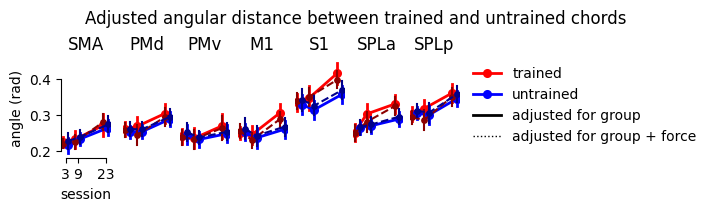

In [47]:
for df in adjusted.values():
        df['theta'] = np.arccos(1 - df.cosine)

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

for a, (label, df) in enumerate(adjusted.items()):
        plot_im_sess(fig, axs, df, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette_ancova[label], kind='point', estimator='mean', dodge=.4, add_zero=False, legend=a==0, **linestyle[label])

        ttest = ttest_im_sess(df, rois, y='theta', x='session', hue='chord', hue_order=hue_order)
        ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
        ttest.sort_values(by=['session', 'roi'], inplace=True)

        print(f'adjusted for {label}')
        print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

handles, labels = axs[-1].get_legend_handles_labels()
handles += [plt.Line2D([0], [0], color='k', **s) for s in style.values()]
labels  += [f'adjusted for {label}' for label in style]
axs[-1].legend([], frameon=False)
fig.legend(handles, labels, frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[0].set_xlabel('session')

fig.suptitle('Adjusted angular distance between trained and untrained chords')

fig.savefig('figures/aagj_ngle_mean.pdf')

plt.show()


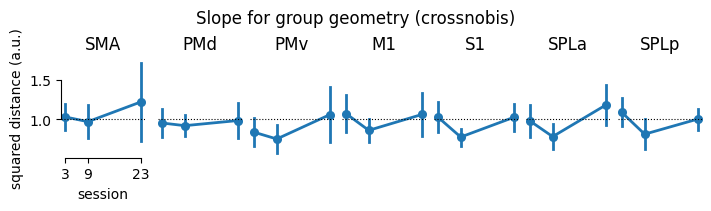

In [11]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess_ancova, rois, y='crossnobis_slope_group', x='session', kind='point', estimator='mean', dodge=.4, add_zero=1)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Slope for group geometry (crossnobis)')

plt.show()

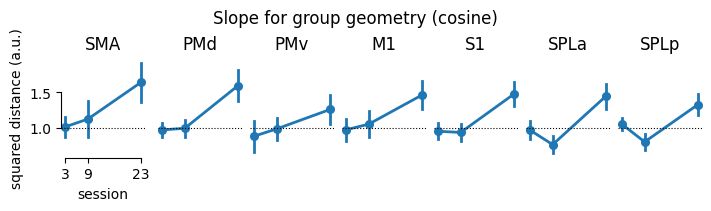

In [12]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess_ancova, rois, y='cosine_slope_group', x='session', kind='point', estimator='mean', dodge=.4, add_zero=1)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Slope for group geometry (cosine)')

plt.show()

# Activity vs. dissimilarity
- Activity $a$ for trained and untrained chords was estimated from the cross-validated G-matrix as: $a = \frac{1}{K}\sum_{k=1}^{K}\sqrt{G_{kk}}$; where $K=4$ is the number of chords within the trained and untrained set.

- Dissimilarity $d$ between trained and untrained chords was estimated as the mean off-diagonal crossnobis distance $d = \frac{2}{K(K-1)}\sum_{k<l}\sqrt{D_{kl}}$ over the same conditions, with $D = $ `pcm.G_to_dist(G)`.

- The predicted dissimilarity in session 9 (and 23) if patterns only scaled with activity would be $\hat d_9 = \frac{a_9}{a_3} d_3$; $d_9 - \hat d_9$ (the `residual`) larger than 0 would occur if the patterns separated by more than a change in activity alone can account for.

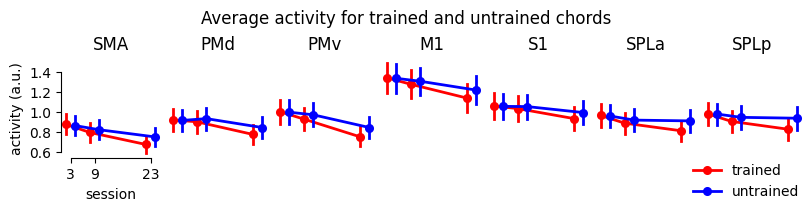

In [13]:
scaling = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'scaling.between_session.glm{glm}.{atlas}.tsv'), sep='\t')
scaling = scaling[scaling.Hem==H]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='act_target', hue='chord', hue_order=hue_order, palette=palette, estimator='mean', add_zero=False, dodge=.4)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('activity (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

fig.suptitle('Average activity for trained and untrained chords')

plt.show()

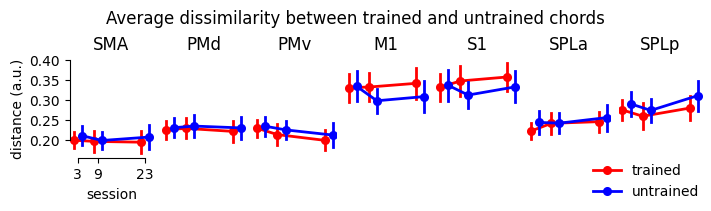

In [14]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois, y='diss_target_observed', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('distance (a.u.)')

fig.suptitle('Average dissimilarity between trained and untrained chords')

plt.show()

           T  dof     p_val          CI95   roi  session
0        NaN   15       NaN    [nan, inf]   SMA        3
3        NaN   15       NaN    [nan, inf]   PMd        3
6        NaN   15       NaN    [nan, inf]   PMv        3
9        NaN   15       NaN    [nan, inf]    M1        3
12       NaN   15       NaN    [nan, inf]    S1        3
15       NaN   15       NaN    [nan, inf]  SPLa        3
18       NaN   15       NaN    [nan, inf]  SPLp        3
7   0.311292   15  0.379932  [-0.03, inf]   PMv        9
13  2.978445   14  0.004984   [0.02, inf]    S1        9
10  1.634585   14  0.062207   [-0.0, inf]    M1        9
4   0.354260   14  0.364212  [-0.02, inf]   PMd        9
1   1.132243   15  0.137654  [-0.01, inf]   SMA        9
16  1.624871   15  0.062506   [-0.0, inf]  SPLa        9
19  0.670176   15  0.256466  [-0.02, inf]  SPLp        9
5   1.173090   15  0.129526  [-0.01, inf]   PMd       23
2   1.413012   15  0.089033  [-0.01, inf]   SMA       23
14  2.975723   15  0.004714   [

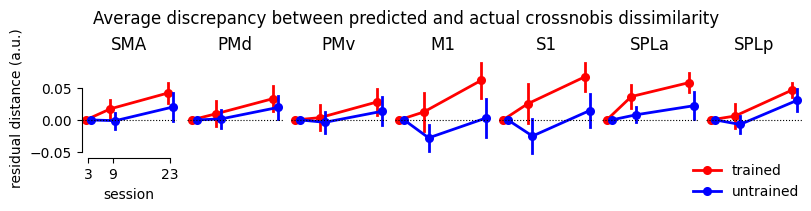

In [48]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='residual', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'], estimator='mean', add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('residual distance (a.u.)')

fig.suptitle('Average discrepancy between predicted and actual crossnobis dissimilarity')

ttest = ttest_im_sess(scaling, rois, y='residual', x='session', hue='chord', hue_order=hue_order, alternative='greater')
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/scaling.pdf')

plt.show()